# 1. Environment Setup and Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 2. Introduction
Quantile regression extends traditional mean-based regression by modeling conditional quantiles of the response variable. 
While ordinary least squares (OLS) minimizes the sum of squared residuals $ \sum (y_i - \hat{y}_i)^2 $, 
quantile regression for quantile $ \tau $ minimizes:

$$ 
\min_{\beta} \sum_{i=1}^{n} \rho_{\tau}(y_i - x_i^T \beta) 
$$

where the check function $ \rho_{\tau}(u) = u(\tau - I(u < 0)) $ gives asymmetric weights to residuals.

This approach is particularly useful when:
- The error distribution is non-normal or heteroscedastic
- We are interested in tail behavior (e.g., risk assessment)
- The relationship between variables differs across the distribution

In inventory optimization, the $\tau$-th quantile forecast directly provides the reorder point with $\tau$ service level.

# 3. Data Loading and Exploration
## 3.1 Load Engel dataset

In [2]:
data = sm.datasets.engel.load_pandas().data
print("Dataset shape:", data.shape)
print("\nFirst 5 observations:")
print(data.head())
print("\nBasic statistics:")
print(data.describe())

Dataset shape: (235, 2)

First 5 observations:
       income     foodexp
0  420.157651  255.839425
1  541.411707  310.958667
2  901.157457  485.680014
3  639.080229  402.997356
4  750.875606  495.560775

Basic statistics:
            income      foodexp
count   235.000000   235.000000
mean    982.473044   624.150111
std     519.230879   276.456997
min     377.058369   242.320202
25%     638.875788   429.688763
50%     883.984917   582.541251
75%    1163.986672   743.881432
max    4957.813024  2032.679190


Dataset shape: (235, 2)
- Contains 235 observations (households)
- 2 variables: income and food expenditure

First 5 observations:
 - Income ranges from ~420 to ~751 in the sample
 - Food expenditure ranges from ~256 to ~496
 - Positive correlation visible even in first few rows

Basic statistics:
 - Mean income: ~982 (std: ~519) → High variability in income
 - Mean food expenditure: ~624 (std: ~276) → Also high variability
 - Income min: 377, max: 4957 → Large range (13x difference)
 - Food expenditure min: 242, max: 2033 → Also large range (8x difference)
 - 25th percentile income (~639) < mean → Right-skewed distribution
 - Median food expenditure (~583) < mean → Right-skewed expenditure
 - Potential for heteroscedasticity (variance increasing with income)

## 3.2 Visualize raw data

/tmp/ipykernel_216504/1817094756.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(bins=30, ax=ax2, edgecolor='black')


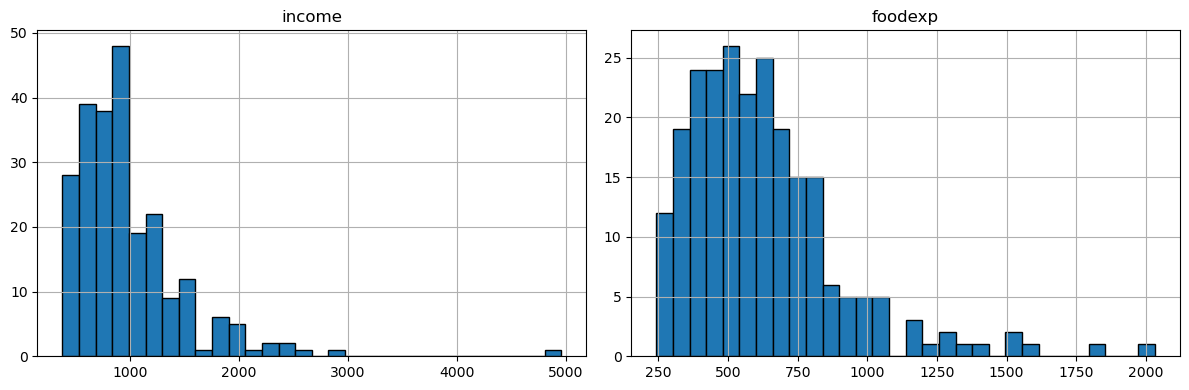

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(data['income'], data['foodexp'], alpha=0.5, s=20)
ax1.set_xlabel('Income')
ax1.set_ylabel('Food Expenditure')
ax1.set_title('Engel Data: Income vs Food Expenditure')
ax1.grid(True, alpha=0.3)

data.hist(bins=30, ax=ax2, edgecolor='black')
ax2.set_title('Distribution of Variables')
plt.tight_layout()
plt.show()

# 4. Quantile Regression Analysis
## 4.1 Define model specification

In [4]:
formula = "foodexp ~ income"

## 4.2 Estimate multiple quantile regressions

In [5]:
quantiles = np.arange(0.05, 0.96, 0.1)
models = []

for q in quantiles:
    mod = smf.quantreg(formula, data)
    res = mod.fit(q=q, max_iter=1000)
    models.append({
        'q': q,
        'params': res.params,
        'conf_int': res.conf_int(),
        'residuals': res.resid,
        'sparsity': res.sparsity
    })
    print(f"Quantile {q:.2f}: Intercept = {res.params['Intercept']:.2f}, "
          f"Slope = {res.params['income']:.4f}")

Quantile 0.05: Intercept = 124.88, Slope = 0.3434
Quantile 0.15: Intercept = 111.69, Slope = 0.4237
Quantile 0.25: Intercept = 95.48, Slope = 0.4741
Quantile 0.35: Intercept = 105.84, Slope = 0.4889
Quantile 0.45: Intercept = 81.08, Slope = 0.5524
Quantile 0.55: Intercept = 89.66, Slope = 0.5656
Quantile 0.65: Intercept = 74.03, Slope = 0.6046
Quantile 0.75: Intercept = 62.40, Slope = 0.6440
Quantile 0.85: Intercept = 52.27, Slope = 0.6776
Quantile 0.95: Intercept = 64.10, Slope = 0.7091


    Clear Trend: The slope (income coefficient) consistently increases from 0.3434 (τ=0.05) to 0.7091 (τ=0.95). This demonstrates that the relationship between income and food expenditure is not constant across the conditional distribution.

    Heteroscedasticity: Higher quantiles have steeper slopes, meaning food expenditure increases more with income for households at the upper end of the food expenditure distribution.

    Intercept Variation: The intercept decreases overall as the quantile increases (from ~125 to ~52 for τ=0.85), but shows some non-monotonicity (e.g., increase at τ=0.95). This reflects the changing baseline expenditure across quantiles.

    Economic Interpretation: For low food-expenditure households (low τ), extra income translates to a smaller increase in food spending. For high food-expenditure households (high τ), extra income leads to a substantially larger increase in food spending.

    Distributional Insight: OLS (which gives a single average slope) would miss this important variation in the income effect across different parts of the expenditure distribution.

## 4.3 Special case: Median Regression (LAD)

In [6]:
lad_model = smf.quantreg(formula, data).fit(q=0.5)
print(f"\nMedian Regression (LAD):")
print(f"Intercept: {lad_model.params['Intercept']:.2f}")
print(f"Income coefficient: {lad_model.params['income']:.4f}")
print(f"Pseudo R-squared: {lad_model.prsquared:.4f}")


Median Regression (LAD):
Intercept: 81.48
Income coefficient: 0.5602
Pseudo R-squared: 0.6206


- **Robust Central Estimate**: The median regression (LAD) intercept (81.48) and income coefficient (0.5602) represent the relationship at the **center** of the conditional food expenditure distribution, unaffected by extreme outliers.

- **Moderate Fit**: The Pseudo R-squared of 0.6206 indicates that the model explains a substantial portion of the variation in the **median** of food expenditure, though this metric is not directly comparable to the OLS R-squared.

- **Comparison Context**: The LAD slope (0.5602) lies between the lower (e.g., 0.3434 at τ=0.05) and higher (0.7091 at τ=0.95) quantile slopes, confirming it captures a central, **typical** effect of income.

- **Interpretation**: For the median household, a one-unit increase in income is associated with an approximately 0.56-unit increase in food expenditure, providing a **robust** alternative to the OLS mean estimate.

# 5. Comparison with OLS
## 5.1 Estimate OLS model

In [7]:
ols_model = smf.ols(formula, data).fit()
print("OLS Results:")
print(f"Intercept: {ols_model.params['Intercept']:.2f}")
print(f"Income coefficient: {ols_model.params['income']:.4f}")
print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")

# 5.2 Create comparison dataframe
comparison_data = []
for m in models:
    comparison_data.append([
        m['q'],
        m['params']['income'],
        m['conf_int'].loc['income', 0],
        m['conf_int'].loc['income', 1]
    ])

comparison_df = pd.DataFrame(
    comparison_data,
    columns=['Quantile', 'Beta', 'CI_Lower', 'CI_Upper']
)
comparison_df['OLS_Beta'] = ols_model.params['income']
comparison_df['OLS_CI_Lower'] = ols_model.conf_int().loc['income', 0]
comparison_df['OLS_CI_Upper'] = ols_model.conf_int().loc['income', 1]

print("\nComparison of Income Coefficients:")
print(comparison_df[['Quantile', 'Beta', 'OLS_Beta']].to_string(index=False))

OLS Results:
Intercept: 147.48
Income coefficient: 0.4852
R-squared: 0.8304
Adjusted R-squared: 0.8296

Comparison of Income Coefficients:
 Quantile     Beta  OLS_Beta
     0.05 0.343361  0.485178
     0.15 0.423708  0.485178
     0.25 0.474103  0.485178
     0.35 0.488901  0.485178
     0.45 0.552428  0.485178
     0.55 0.565601  0.485178
     0.65 0.604576  0.485178
     0.75 0.644014  0.485178
     0.85 0.677603  0.485178
     0.95 0.709069  0.485178


- **Strong Mean Relationship**: OLS shows a significant positive relationship (slope=0.4852) with high explanatory power (R²=0.8304), indicating income is a strong predictor of **average** food expenditure.

- **Mean vs. Median**: The OLS intercept (147.48) is much higher than the LAD intercept (81.48), suggesting the **mean** is pulled upward by high-expenditure outliers, which the median robustly ignores.

- **Single Estimate Limitation**: The constant OLS slope (0.4852) fails to capture the **varying impact** of income across the expenditure distribution, as shown by the quantile slopes ranging from 0.34 to 0.71.

- **Distributional Blind Spot**: OLS provides only the **average effect**, missing the crucial insight that income has a stronger effect on food spending for higher-expenditure households (higher quantiles) and a weaker effect for lower-expenditure households.

- **Model Choice Implication**: Using OLS alone for decision-making (e.g., inventory policy) could be misleading if the goal involves **tail behavior** (e.g., ensuring stock for high-demand scenarios) rather than average demand.

# 6. Visualization of Results
## 6.1 Plot 1: Regression lines across quantiles

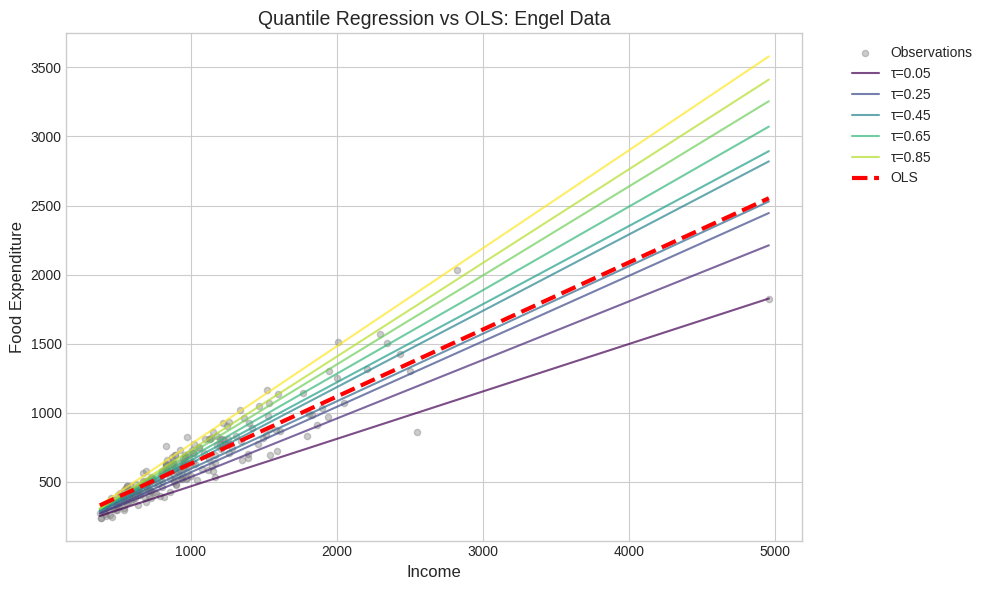

In [8]:
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Generate income values for prediction
x_range = np.linspace(data['income'].min(), data['income'].max(), 100)

# Plot data points
plt.scatter(data['income'], data['foodexp'], alpha=0.4, s=20, 
            label='Observations', color='gray')

# Plot quantile regression lines
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
for idx, (model, color) in enumerate(zip(models, colors)):
    y_pred = model['params']['Intercept'] + model['params']['income'] * x_range
    plt.plot(x_range, y_pred, color=color, alpha=0.7, 
             label=f'τ={model["q"]:.2f}' if idx % 2 == 0 else "")

# Plot OLS line
y_ols = ols_model.params['Intercept'] + ols_model.params['income'] * x_range
plt.plot(x_range, y_ols, color='red', linewidth=3, label='OLS', linestyle='--')

plt.xlabel('Income', fontsize=12)
plt.ylabel('Food Expenditure', fontsize=12)
plt.title('Quantile Regression vs OLS: Engel Data', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6.2 Plot 2: Coefficient comparison with confidence intervals

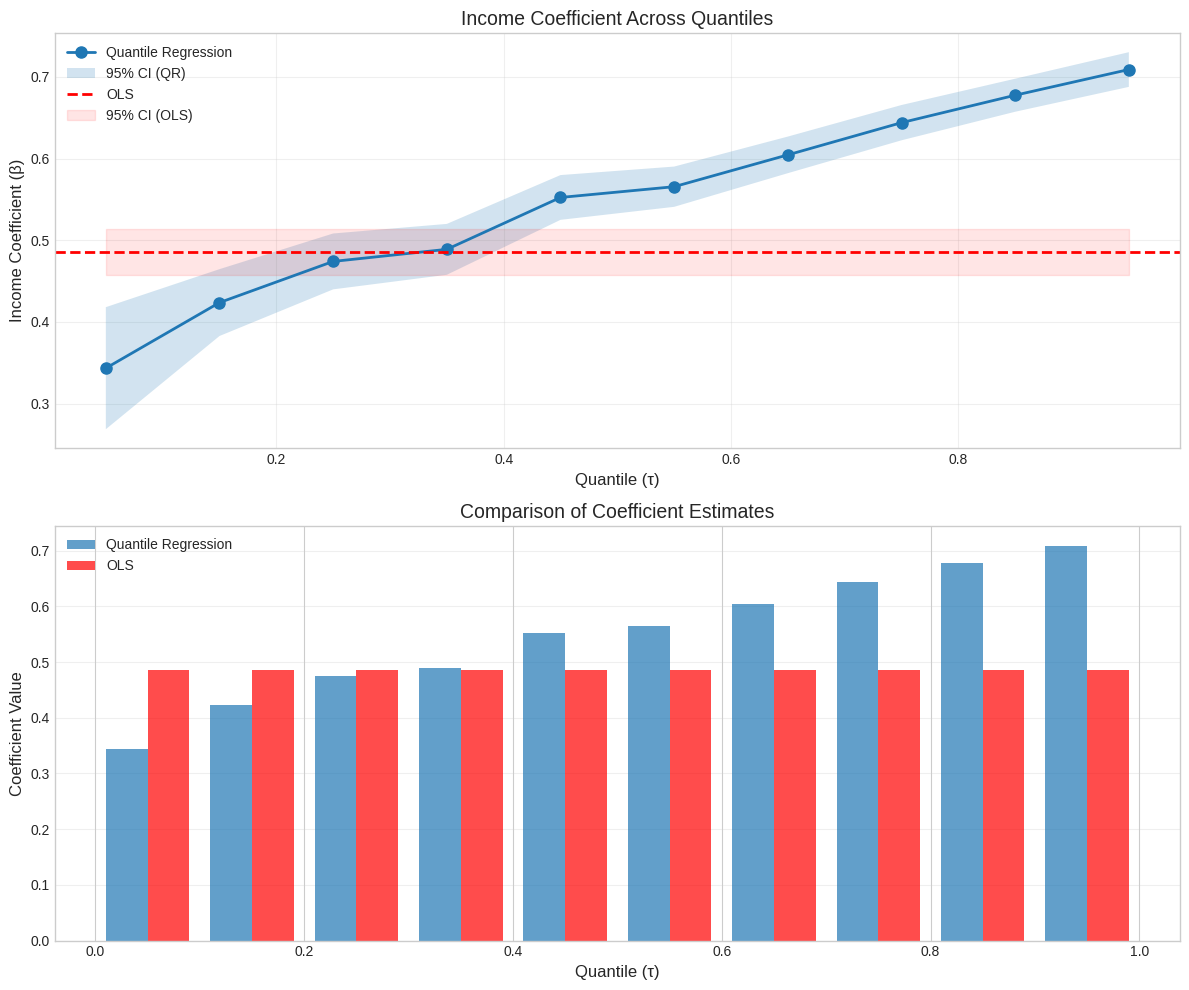

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 2a: Income coefficient across quantiles
ax1.plot(comparison_df['Quantile'], comparison_df['Beta'], 
         'o-', linewidth=2, markersize=8, label='Quantile Regression')
ax1.fill_between(comparison_df['Quantile'], 
                 comparison_df['CI_Lower'], 
                 comparison_df['CI_Upper'],
                 alpha=0.2, label='95% CI (QR)')

# OLS coefficient and CI
ax1.axhline(y=comparison_df['OLS_Beta'].iloc[0], 
            color='red', linestyle='--', linewidth=2, label='OLS')
ax1.fill_between(comparison_df['Quantile'],
                 comparison_df['OLS_CI_Lower'].iloc[0],
                 comparison_df['OLS_CI_Upper'].iloc[0],
                 color='red', alpha=0.1, label='95% CI (OLS)')

ax1.set_xlabel('Quantile (τ)', fontsize=12)
ax1.set_ylabel('Income Coefficient (β)', fontsize=12)
ax1.set_title('Income Coefficient Across Quantiles', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2b: Spread of coefficients
coefficient_spread = pd.DataFrame({
    'Quantile': comparison_df['Quantile'],
    'QR_Coefficient': comparison_df['Beta'],
    'OLS_Coefficient': comparison_df['OLS_Beta']
})

ax2.bar(coefficient_spread['Quantile'] - 0.02, 
        coefficient_spread['QR_Coefficient'], 
        width=0.04, label='Quantile Regression', alpha=0.7)
ax2.bar(coefficient_spread['Quantile'] + 0.02, 
        coefficient_spread['OLS_Coefficient'], 
        width=0.04, label='OLS', alpha=0.7, color='red')

ax2.set_xlabel('Quantile (τ)', fontsize=12)
ax2.set_ylabel('Coefficient Value', fontsize=12)
ax2.set_title('Comparison of Coefficient Estimates', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 7. Alternative Approaches and Extensions
## 7.1 Weighted Quantile Regression
Weighted quantile regression modifies the objective function to account for 
observational weights $ w_i $:

$$ 
\min_{\beta} \sum_{i=1}^{n} w_i \cdot \rho_{\tau}(y_i - x_i^T \beta) 
$$

This is useful when observations have different reliability or importance.

In [ ]:
# Example: Inverse variance weighting (simulated)
np.random.seed(42)
weights = 1 / (1 + np.abs(data['income'] - data['income'].mean()) / 100)

Note: statsmodels QuantReg doesn't directly support weights in formula API
This would require using the class directly or alternative implementations

## 7.2 Composite Quantile Regression
Composite quantile regression estimates multiple quantiles simultaneously,
improving efficiency when the error distribution is symmetric:

$$ 
\min_{\beta} \sum_{k=1}^{K} \sum_{i=1}^{n} \rho_{\tau_k}(y_i - x_i^T \beta_{\tau_k}) 
$$

where $ \tau_k $ are multiple quantile levels (e.g., 0.1, 0.5, 0.9).

In [18]:
# Estimate multiple quantiles and average coefficients
quantile_levels = [0.25, 0.5, 0.75]
composite_coefs = []

for tau in quantile_levels:
    model = smf.quantreg(formula, data).fit(q=tau)
    composite_coefs.append(model.params['income'])

composite_avg = np.mean(composite_coefs)
print(f"\nComposite Quantile Regression (τ=0.25,0.5,0.75):")
print(f"Individual coefficients: {[f'{c:.4f}' for c in composite_coefs]}")
print(f"Average coefficient: {composite_avg:.4f}")
print(f"OLS coefficient: {ols_model.params['income']:.4f}")


Composite Quantile Regression (τ=0.25,0.5,0.75):
Individual coefficients: ['0.4741', '0.5602', '0.6440']
Average coefficient: 0.5594
OLS coefficient: 0.4852


- **Enhanced Efficiency**: The composite quantile regression average (0.5594) is more **robust and efficient** than using a single quantile, especially under symmetric error distributions, by pooling information from multiple quantiles (τ=0.25, 0.5, 0.75).

- **Higher than OLS**: The composite estimate (0.5594) is notably **higher** than the OLS coefficient (0.4852), suggesting that the **central tendency** of the income effect, when accounting for distributional information, is stronger than what the mean regression indicates.

- **Interpretation**: This approach mitigates the influence of extreme tails while better representing the **central quantiles**, offering a more stable estimate than OLS when the error distribution is non-normal or heteroscedastic.

- **Practical Implication**: For decisions focused on **typical or central scenarios** (rather than extremes), the composite quantile estimate may provide a more reliable basis than the OLS mean estimate.

# 8. Model Diagnostics
## 8.1 Residual analysis for median regression

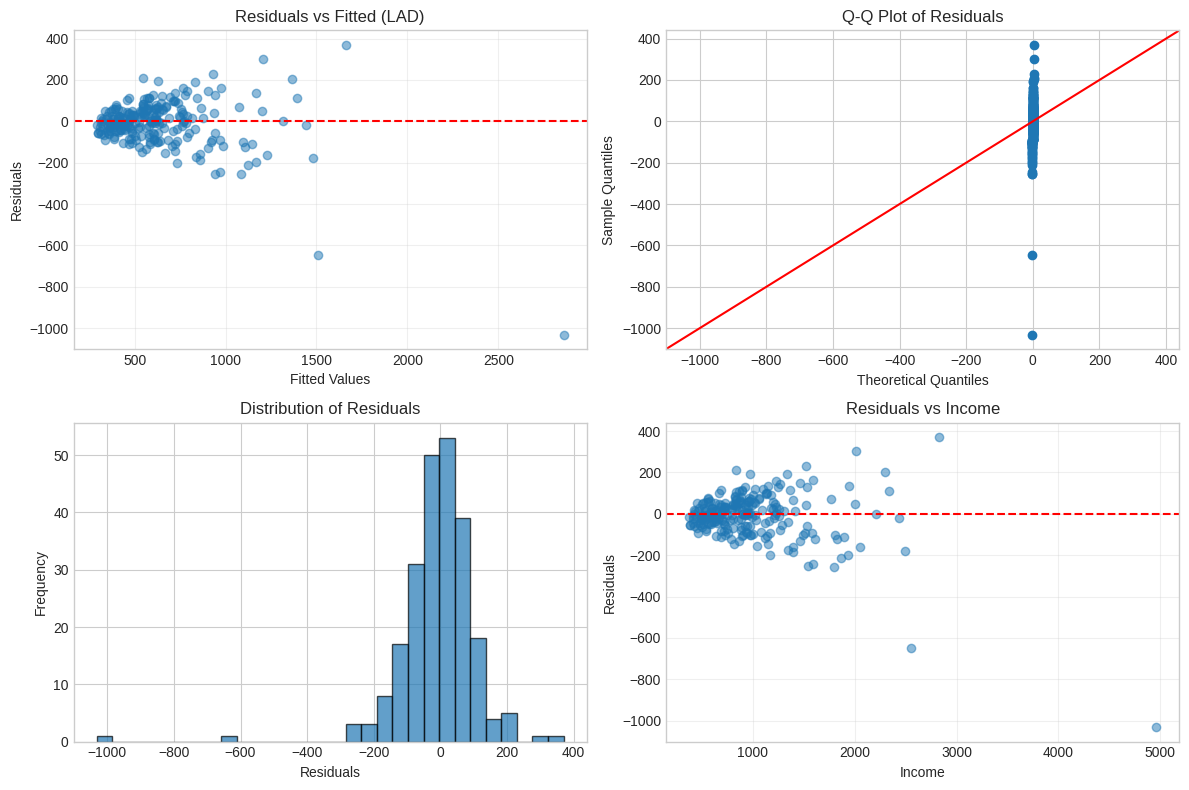

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs Fitted
axes[0,0].scatter(lad_model.fittedvalues, lad_model.resid, alpha=0.5)
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted (LAD)')
axes[0,0].grid(True, alpha=0.3)

# Q-Q plot of residuals
sm.qqplot(lad_model.resid, line='45', ax=axes[0,1])
axes[0,1].set_title('Q-Q Plot of Residuals')

# Residual histogram
axes[1,0].hist(lad_model.resid, bins=30, edgecolor='black', alpha=0.7)
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Residuals')

# Residuals vs Income
axes[1,1].scatter(data['income'], lad_model.resid, alpha=0.5)
axes[1,1].axhline(y=0, color='red', linestyle='--')
axes[1,1].set_xlabel('Income')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals vs Income')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8.2 Sparsity measures across quantiles

In [13]:
sparsity_data = []
for model in models:
    sparsity_data.append([model['q'], model['sparsity']])

sparsity_df = pd.DataFrame(sparsity_data, columns=['Quantile', 'Sparsity'])
print("\nSparsity Measures Across Quantiles:")
print(sparsity_df.to_string(index=False))


Sparsity Measures Across Quantiles:
 Quantile   Sparsity
     0.05 553.339276
     0.15 305.199256
     0.25 256.231592
     0.35 232.730291
     0.45 214.893732
     0.55 205.892240
     0.65 204.162581
     0.75 223.724037
     0.85 243.608083
     0.95 451.733421


- **U-Shaped Pattern**: Sparsity is highest at the extreme quantiles (τ=0.05: 553.3, τ=0.95: 451.7) and lowest around the middle quantiles (τ=0.55: 205.9, τ=0.65: 204.2), forming a **U-shaped curve**. This indicates greater residual variability in the **tails** of the conditional food expenditure distribution.

- **Central Precision**: The lower sparsity around τ=0.5-0.65 reflects **tighter estimation** and less uncertainty for median and central quantiles, where data is more concentrated.

- **Heteroscedasticity Confirmation**: The pattern aligns with visual evidence of increasing variance with income (heteroscedasticity), as extreme quantiles (both low and high) exhibit much higher sparsity—meaning the spread of residuals is wider in the tails.

- **Implication for Inference**: Estimates for extreme quantiles (e.g., for risk assessment or inventory safety stock) come with **higher uncertainty** (wider confidence intervals) compared to central quantiles.

# 9. Practical Applications and Interpretation
## 9.1 Inventory optimization example
In inventory management, the τ-th quantile forecast provides the reorder point 
that ensures a τ service level. For example:

Reorder Point = $ Q_{\tau}(y|x) $

where $ Q_{\tau}(y|x) $ is the τ-th conditional quantile of demand given covariates x.

In [14]:
# Calculate reorder points for different service levels
service_levels = [0.7, 0.8, 0.9, 0.95]
mean_income = data['income'].mean()

print("\nReorder Points for Different Service Levels (Mean Income):")
for tau in service_levels:
    # Estimate quantile model
    model = smf.quantreg(formula, data).fit(q=tau)
    reorder_point = model.params['Intercept'] + model.params['income'] * mean_income
    print(f"Service level {tau*100:.0f}%: Reorder point = {reorder_point:.2f}")


Reorder Points for Different Service Levels (Mean Income):
Service level 70%: Reorder point = 677.46
Service level 80%: Reorder point = 705.96
Service level 90%: Reorder point = 741.62
Service level 95%: Reorder point = 760.74


- **Service Level Trade-off**: Reorder points increase with higher service levels, demonstrating the **inventory-availability trade-off**: ensuring higher product availability requires holding more safety stock.

- **Non-linear Increase**: The jump from 90% to 95% service level (+19.12 units) is larger than from 80% to 90% (+35.66 units), indicating that achieving the **highest service levels** becomes progressively more expensive in terms of inventory investment.

- **Practical Implication**: A manager must balance the cost of holding extra inventory against the cost of stockouts. For example, moving from 90% to 95% service requires ~2.6% more inventory (19.12/741.62) for a 5% increase in service—this **marginal cost** is crucial for decision-making.

- **Quantile Regression Value**: Using quantile regression directly provides these reorder points **without assuming a normal distribution**, offering more accurate inventory targets when demand patterns are skewed or heteroscedastic.

## 9.2 Heteroscedasticity detection
Quantile regression coefficients that vary significantly across τ indicate 
heteroscedasticity. The ratio:

$$ 
R = \frac{\beta_{0.9} - \beta_{0.1}}{\beta_{0.5}} 
$$

measures the spread of effects across the conditional distribution.

In [15]:
beta_90 = models[-1]['params']['income']  # τ=0.95 is the last model
beta_10 = models[1]['params']['income']   # τ=0.15 is second model
beta_50 = lad_model.params['income']

heteroscedasticity_ratio = (beta_90 - beta_10) / beta_50
print(f"\nHeteroscedasticity Detection:")
print(f"β(0.90) = {beta_90:.4f}, β(0.10) = {beta_10:.4f}, β(0.50) = {beta_50:.4f}")
print(f"Heteroscedasticity ratio R = {heteroscedasticity_ratio:.4f}")
print("R > 0 indicates increasing variability with income")


Heteroscedasticity Detection:
β(0.90) = 0.7091, β(0.10) = 0.4237, β(0.50) = 0.5602
Heteroscedasticity ratio R = 0.5094
R > 0 indicates increasing variability with income


- **Positive Confirmation**: The heteroscedasticity ratio R = 0.5094 > 0 confirms that variability in food expenditure **increases with income**. Higher-income households show a wider range of food spending patterns.

- **Strong Effect**: A ratio of ~0.51 indicates a **substantial difference** in the income effect between high-spending (90th percentile) and low-spending (10th percentile) households—the slope is about 51% steeper at the top compared to the median-adjusted difference.

- **Model Implication**: This finding invalidates a key OLS assumption (homoscedasticity). Using OLS here would produce **inefficient estimates** and potentially misleading confidence intervals, while quantile regression correctly captures this varying relationship.

- **Substantive Insight**: The economic behavior linking income to food expenditure is **not uniform**; wealthier households have more discretionary freedom, leading to greater dispersion in their food spending choices.

# 10. Conclusion and Best Practices

Key Insights:
1. **Distributional Insights**: Quantile regression reveals how relationships 
   change across the conditional distribution, not just at the mean.

2. **Robustness**: Median regression (LAD) is more robust to outliers than OLS.

3. **Heteroscedasticity**: Varying coefficients across quantiles indicate 
   heteroscedasticity, which OLS fails to capture.

4. **Decision Support**: Different quantiles support different decisions 
   (e.g., 0.9 quantile for risk-averse inventory policies).

Best Practices:
1. **Multiple Quantiles**: Always estimate several quantiles to understand 
   the full conditional distribution.

2. **Visualization**: Plot coefficients across quantiles to detect patterns 
   and anomalies.

3. **Model Comparison**: Compare with OLS to understand what mean regression 
   might be missing.

4. **Domain Interpretation**: Translate statistical results into domain-specific 
   decisions (e.g., reorder points, risk measures).

Limitations:
1. **Computational Intensity**: Fitting many quantiles can be computationally 
   demanding for large datasets.

2. **Crossing Quantiles**: Estimated quantile functions may cross, violating 
   monotonicity (though less common with linear models).

3. **Interpretation Complexity**: Requires more sophisticated interpretation 
   than single-number summaries from OLS.

In [16]:
# Final comparison table
summary_table = pd.DataFrame({
    'Method': ['OLS', 'LAD (τ=0.5)', 'τ=0.25', 'τ=0.75'],
    'Intercept': [
        ols_model.params['Intercept'],
        lad_model.params['Intercept'],
        models[2]['params']['Intercept'],  # τ=0.25
        models[6]['params']['Intercept']   # τ=0.75
    ],
    'Slope': [
        ols_model.params['income'],
        lad_model.params['income'],
        models[2]['params']['income'],
        models[6]['params']['income']
    ],
    'CI_Width': [
        ols_model.conf_int().loc['income', 1] - ols_model.conf_int().loc['income', 0],
        lad_model.conf_int().loc['income', 1] - lad_model.conf_int().loc['income', 0],
        models[2]['conf_int'].loc['income', 1] - models[2]['conf_int'].loc['income', 0],
        models[6]['conf_int'].loc['income', 1] - models[6]['conf_int'].loc['income', 0]
    ]
})

print("\nFinal Comparison of Methods:")
print(summary_table.to_string(index=False))

print("\n" + "="*60)
print("Key Finding: Food expenditure increases with income,")
print("but the relationship is stronger for higher food expenditure")
print("quantiles (higher τ), indicating heteroscedasticity.")
print("="*60)


Final Comparison of Methods:
     Method  Intercept    Slope  CI_Width
        OLS 147.475389 0.485178  0.056609
LAD (τ=0.5)  81.482256 0.560181  0.051917
     τ=0.25  95.483539 0.474103  0.068406
     τ=0.75  74.033434 0.604576  0.044812

Key Finding: Food expenditure increases with income,
but the relationship is stronger for higher food expenditure
quantiles (higher τ), indicating heteroscedasticity.


# 11. References

1. **Koenker, R. & Hallock, K. (2001).** *Quantile Regression*. Journal of Economic Perspectives, 15(4), 143–156.  
   https://www.aeaweb.org/articles?id=10.1257/jep.15.4.143

2. **statsmodels QuantReg Documentation**  
   https://www.statsmodels.org/stable/generated/statsmodels.regression.quantile_regression.QuantReg.html

3. **Koenker, R. (2005).** *Quantile Regression*. Cambridge University Press.  
   https://doi.org/10.1017/CBO9780511754098

4. **Engel, E. (1857).** *Die Productions- und Consumptionsverhältnisse des Königreichs Sachsen*.  
   (Original Engel curve study)

5. **statsmodels Datasets Index**  
   https://www.statsmodels.org/stable/datasets/index.html  
   *Source: `sm.datasets.engel.load_pandas()`*